# Baselines e MLflow

Três modelos no mesmo `X` e `y`, com **validação cruzada estratificada** (5 *folds*), e um *run* no MLflow por modelo. Depois dá para comparar com a MLP noutro notebook e com o que o enunciado pedia (logística, árvore, *dummy*).

1. **`*DummyClassifier*` estratificado** — atira a classe à sorte, mas respeitando a proporção de churn. É o chão: ROC-AUC ~0,5, PR-AUC ~taxa de positivos (a taxa real sai no print abaixo). Tudo o que for treinado a sério tem de bater isto.
2. **Regressão logística** — mesmo pré-processamento + linear; em tabelas deste tipo costuma ser difícil de bater sem complicar.
3. **Random Forest** — `pipeline_random_forest` em `baselines.py`. O `RandomForestClassifier` fica com `n_jobs=1` para não competir com o `cross_validate(..., n_jobs=-1)` (senão o Windows costuma entupir de *threads*).

O `ColumnTransformer` é o mesmo para os três (`build_preprocessor`: mediana + escala nos números; moda + *one-hot* nas categorias). *Seed* e `N_CV_SPLITS` vêm de `config.py`.

O limiar **0,35**, a ideia de custo FP/FN e o porquê de olhar para PR-AUC estão em `docs/metricas_e_limiar.md`; os mesmos números vão como *params* no MLflow. O `cross_validate` em baixo usa as métricas padrão do sklearn (o F1 desse bloco é com corte 0,5 no `predict`); noutro passo calculamos F1 no **0,35** com probabilidades *out-of-fold*.

**Diretório de trabalho:** abre o Jupyter na **raiz** do `tech_challenge_fase_01` ou em `notebooks/` — a próxima célula sobe o `sys.path` e manda o MLflow gravar em `mlruns/` na raiz.


In [1]:
# Raiz do repositório: se o kernel estiver em notebooks/, sobe um nível
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import mlflow
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate

from churn_prediction.baselines import (
    build_preprocessor,
    pipeline_dummy,
    pipeline_logistic,
    pipeline_random_forest,
)
from churn_prediction.config import (
    MLFLOW_EXPERIMENT_BASELINES,
    N_CV_SPLITS,
    RANDOM_SEED,
    THRESHOLD_START,
)
from churn_prediction.datasets import load_churn_telco, make_X_y

# file:.../mlruns — pasta local (ver README: python -m mlflow ui --backend-store-uri file:./mlruns)
mlflow.set_tracking_uri(f"file:{ROOT / 'mlruns'}")
mlflow.set_experiment(MLFLOW_EXPERIMENT_BASELINES)


C:\Users\Primodeckers\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:D:\\tech-challenge-fase-one\\tech_challenge_fase_01/mlruns/358933226733374888', creation_time=1777845983710, experiment_id='358933226733374888', last_update_time=1777845983710, lifecycle_stage='active', name='telco_churn_baselines', tags={}, trace_location=None, workspace='default'>

## Dados e matriz `X` / vetor `y`

`load_churn_telco` lê o Excel, converte `Total Charges` com `pd.to_numeric(..., errors="coerce")` e **remove** linhas em que o total não é um número válido (no Telco são poucas — o código a seguir mostra a contagem antes do *drop*).

`make_X_y` monta o alvo binário (`Churn Label` == `Yes` → 1) e constrói `X` retirando as colunas listadas em `DROP_FOR_MODELING` em `datasets.py`:

- **Identificação:** `CustomerID`
- **Alvo e derivados diretos do churn:** `Churn Label`, `Churn Reason`, `Churn Value`
- **Suspeitas de *leakage* ou pós-evento:** `Churn Score`, `CLTV`
- **Localização fina:** `Lat Long`

O `Shape X` abaixo mostra quantas colunas de *feature* ficam (números e categorias); as três *pipelines* usam o mesmo pré-processamento.


In [2]:
path = ROOT / "data" / "raw" / "Telco_customer_churn.xlsx"

import hashlib


def _file_sha256(p: Path) -> str:
    h = hashlib.sha256()
    with p.open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


DATASET_SHA256 = _file_sha256(path)

raw = pd.read_excel(path)
# Linhas com Total Charges que não viram número (no bruto, antes do drop do load_churn_telco)
n_bad_total_charges = pd.to_numeric(raw["Total Charges"], errors="coerce").isna().sum()

df = load_churn_telco(path)
X, y = make_X_y(df)

print("Linhas após limpar Total Charges:", len(df))
print("Linhas com Total Charges inválido (antes do drop):", int(n_bad_total_charges))
print("Shape X:", X.shape, "| positivos (churn):", int(y.sum()), "| taxa churn:", round(100 * y.mean(), 2), "%")


Linhas após limpar Total Charges: 7032
Linhas com Total Charges inválido (antes do drop): 11
Shape X: (7032, 26) | positivos (churn): 1869 | taxa: 26.58 %


## Validação cruzada e MLflow

`StratifiedKFold` com *shuffle* fixo pela mesma *seed*: em cada *fold* a taxa de churn fica parecida com a da base (a minoria não some num *fold* só).

Quatro métricas no `cross_validate`; no MLflow ficam `*_mean` e `*_std` entre os 5 *folds*:

| Métrica | Nota rápida |
|--------|-------------|
| **ROC-AUC** | Ordenação dos scores; com classe desequilibrada pode parecer alta sem o modelo ser grande coisa. |
| **PR-AUC** (`average_precision`) | O que estamos a priorizar para comparar *runs* (ver `metricas_e_limiar.md`). |
| **F1** | Com o corte **0,5** do `predict` dentro de cada *fold* — é o default do sklearn, não o nosso limiar de negócio. |
| **Balanced accuracy** | Vê se o modelo não está só a acertar "não churn". |

Três *runs* (`dummy_stratified`, `logistic_regression`, `random_forest`). Em cada um entram *params* com *seed*, tamanho dos dados, custos fictícios FP/FN e `threshold_start` para documentar o raciocínio de custo FP/FN.

Depois do CV vêm as probabilidades **out-of-fold** (cada linha foi predita por um modelo que não a viu no treino). Aí aplicamos `THRESHOLD_START` (0,35 no `config`) e calculamos **`f1_at_threshold_start`** — é o F1 na classe churn **nesse** corte, o que bate com o que discutiram no doc de métricas.


In [3]:
oof_proba = {}  # P(churn) OOF — uso nas matrizes de confusão em baixo

cv = StratifiedKFold(
    n_splits=N_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_SEED,
)
scoring = ["roc_auc", "average_precision", "f1", "balanced_accuracy"]

pre = build_preprocessor(X)

pipelines = {
    "dummy_stratified": pipeline_dummy(pre),
    "logistic_regression": pipeline_logistic(pre),
    "random_forest": pipeline_random_forest(pre),
}

for name, pipe in pipelines.items():
    with mlflow.start_run(run_name=name):
        mlflow.log_params(
            {
                "random_seed": RANDOM_SEED,
                "cv_splits": N_CV_SPLITS,
                "dataset_file": path.name,
                "dataset_sha256": DATASET_SHA256,
                "n_rows": len(X),
                "n_features_raw": X.shape[1],
                "cost_fn_relative": 2,
                "cost_fp_relative": 1,
                "threshold_start": THRESHOLD_START,
                "primary_metric": "average_precision",
            }
        )
        mlflow.log_param("rows_total_charges_invalid_raw", int(n_bad_total_charges))

        scores = cross_validate(
            pipe,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
        )
        for m in scoring:
            key = f"test_{m}"
            mlflow.log_metric(f"{m}_mean", float(scores[key].mean()))
            mlflow.log_metric(f"{m}_std", float(scores[key].std()))

        # Coluna 1 = probabilidade da classe churn (positiva)
        y_proba_oof = cross_val_predict(
            pipe, X, y, cv=cv, method="predict_proba", n_jobs=-1
        )[:, 1]
        oof_proba[name] = y_proba_oof
        y_thr = (y_proba_oof >= THRESHOLD_START).astype(int)
        f1_thr = float(f1_score(y, y_thr))
        mlflow.log_metric("f1_at_threshold_start", f1_thr)

        row_cv = {m: round(float(scores[f"test_{m}"].mean()), 4) for m in scoring}
        print(name, row_cv, "| F1 @", THRESHOLD_START, "=", round(f1_thr, 4))

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experimento:", MLFLOW_EXPERIMENT_BASELINES)


dummy_stratified {'roc_auc': np.float64(0.484), 'average_precision': np.float64(0.2601), 'f1': np.float64(0.2429), 'balanced_accuracy': np.float64(0.484)} | F1 @ 0.35 = 0.2429
logistic_regression {'roc_auc': np.float64(0.8498), 'average_precision': np.float64(0.6544), 'f1': np.float64(0.6011), 'balanced_accuracy': np.float64(0.7256)} | F1 @ 0.35 = 0.6363
random_forest {'roc_auc': np.float64(0.8536), 'average_precision': np.float64(0.664), 'f1': np.float64(0.6419), 'balanced_accuracy': np.float64(0.7696)} | F1 @ 0.35 = 0.6163
Tracking URI: file:d:\tech-challenge-fase-one\tech_challenge_fase_01\mlruns
Experimento: telco_churn_baselines


### Sobre os números que saem no print

A **Random Forest** muitas vezes ganha na PR-AUC e na *balanced accuracy* em relação à logística; o **F1 @ 0,35** às vezes fica ligeiramente pior que na logística porque o corte 0,35 interage de forma diferente com a forma da curva de probabilidades — não é bug, é o limiar. O *dummy* fica no chão; se não ficar, algo correu mal.

Isto muda com *seed*, versão de biblioteca e máquina; o que interessa é a **ordem de grandeza** e a diferença entre modelos no **mesmo** *run* de notebook.

## Limiar e matriz de confusão

Cada coluna de `oof_proba` saiu de predições feitas com o modelo treinado **sem** essa linha (OOF), por isso não estamos a inspecionar o *train set*.

Com `THRESHOLD_START` (0,35, igual ao `config` e ao `metricas_e_limiar.md`), contamos **churn** se `P(churn) >=` esse valor. O F1 nesse corte já foi para o MLflow (`f1_at_threshold_start`).

As figuras abaixo mostram FP/FN para os três modelos ao mesmo tempo. Se no teu *story* de negócio FN pesa mais, um limiar abaixo de 0,5 puxa *recall* e admite mais FP — daí o 0,35.

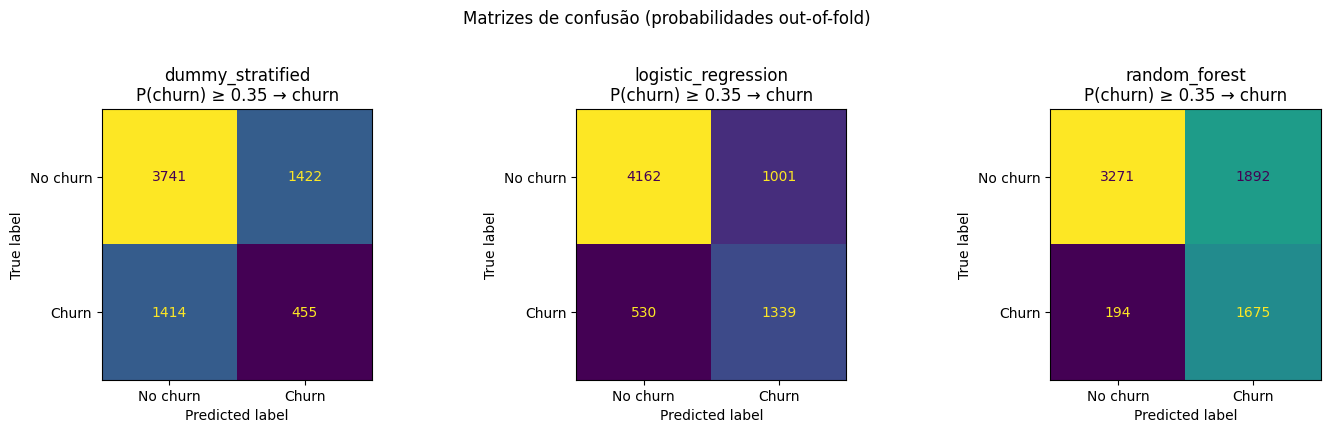

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(pipelines), figsize=(4.8 * len(pipelines), 4.2))
if len(pipelines) == 1:
    axes = [axes]

for ax, (name, _) in zip(axes, pipelines.items()):
    y_proba_oof = oof_proba[name]
    y_pred_thr = (y_proba_oof >= THRESHOLD_START).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y,
        y_pred_thr,
        display_labels=["No churn", "Churn"],
        ax=ax,
        colorbar=False,
        values_format="d",
    )
    ax.set_title(f"{name}\nP(churn) ≥ {THRESHOLD_START} → churn")

plt.suptitle("Confusão no limiar de negócio (scores OOF)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Onde ver isto no MLflow

Tudo foi para **`mlruns/`** na raiz do repo (pasta local, no `.gitignore` — quem clonar o repo não vê os mesmos números até correr o notebook localmente ou copiar `mlruns/`).

Na raiz do projeto, com o venv ativo:

```
python -m mlflow ui --backend-store-uri file:./mlruns
```

Abre o URL no browser (muitas vezes `http://127.0.0.1:5000`), experimento **`telco_churn_baselines`**. Procura a lista de *runs* em **Runs** ou **Run evaluations** (depende da versão da UI). O separador **Traces** não é para estes modelos — fica vazio.

Devias ver três *runs* com nome `dummy_stratified`, `logistic_regression`, `random_forest`. Métricas: `roc_auc_mean`, `average_precision_mean`, etc., e `f1_at_threshold_start`.

Aviso do MLflow sobre *file store* *deprecated* dá para ignorar no challenge. O *param* `dataset_sha256` no MLflow identifica a versão do ficheiro Excel usado.
